In [3]:
require(data.table)
require(tidyverse)
require(dplyr)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

# Does clade change with health_status?

In [35]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/RDS/ps_ITS2.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 417 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 417 taxa by 8 taxonomic ranks ]

In [36]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps, function(x) 1E6 * x / sum(x))

## cleaning sample_data

In [37]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_norm) {
  sd <- sample_data(ps_norm)
  return(as(sd,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample <- pssd2veg(ps_norm)

In [38]:
sample <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample$SampleID <- rownames(sample)

### dates in chronological order

In [39]:
# 2. reorder MonthYear as a factor in chronological order
sample$Month_year <- factor(sample$Month_year,levels = unique(sample$Month_year))

## merging back into ps object

In [40]:
# Restore rownames
rownames(sample) <- sample$SampleID
#check
head(rownames(sample))
NROW(sample_names(ps_norm))

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

[1] 475

In [41]:
#take the filtered metadata I just worked on — with cleaned rows, and correct sample names — and replace the old sample data in ps_clean with this cleaned version
sd_clean <- phyloseq::sample_data(sample)
sample_data(ps_norm) <- sd_clean
head(sample_data(ps_norm))

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted,SampleID
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<chr>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,2024-01-10,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,2024-01-10,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,2024-01-10,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12,012024_BEL_CBC_T2_585_OFAV


## taxa

### clade by health status

In [42]:
# use merge taxa instead of tax_glom bc things in the same clade may not necessarily be heirarchal
ps_clade <- merge_taxa(ps_norm, "Clade")

In [43]:
## assigning colors
clade <- unique(tax_table(ps_clade)[, "Clade"])

base_palette <- colorRampPalette(brewer.pal(9, "Set1"))(9)

cladecolors <- sample(base_palette, length(clade))
cladecolors <- setNames(cladecolors, clade)

In [44]:
head(sample_data(ps_clade))

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted,SampleID
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<chr>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,2024-01-10,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,2024-01-10,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,2024-01-10,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12,012024_BEL_CBC_T2_585_OFAV


In [45]:
#make dates be in chronological order

# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_clade)$Month_year <- factor(sample_data(ps_clade)$Month_year,levels = c("Jun 2019","May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))



<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


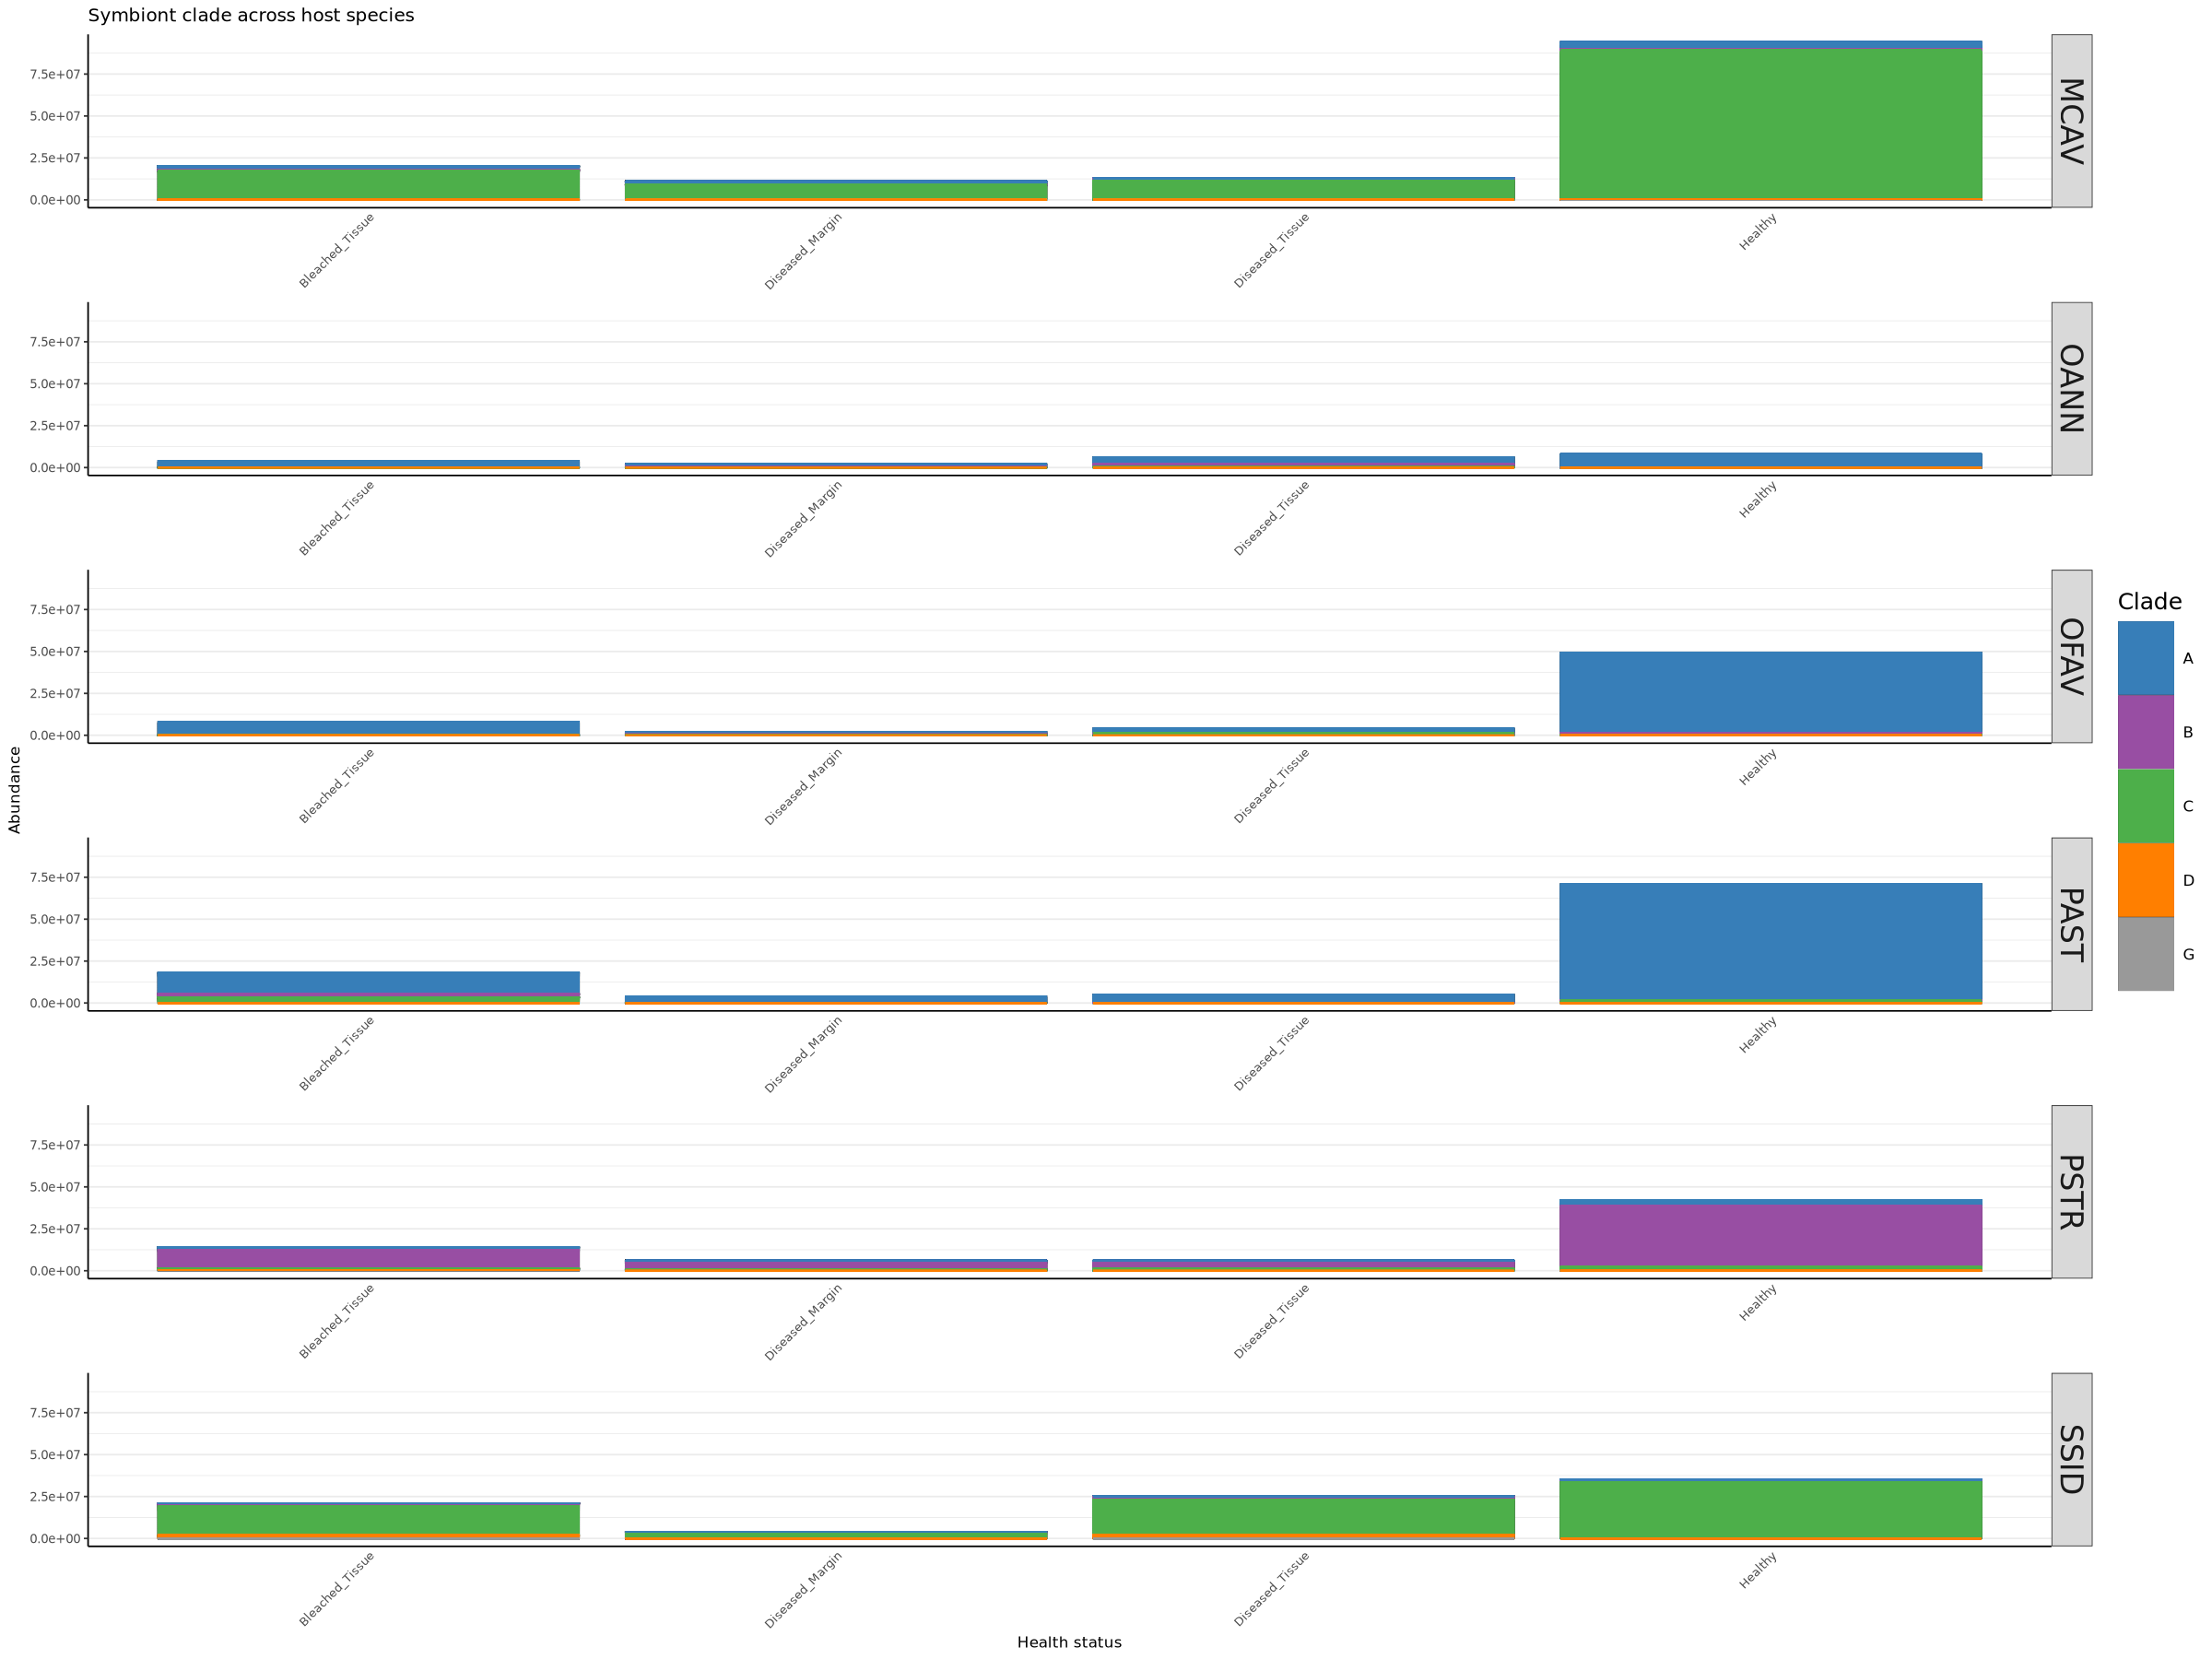

In [48]:
## plot

health_clade <- plot_bar(ps_clade, x= "Health_status", fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_x") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Health status",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size =10)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_clade

<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


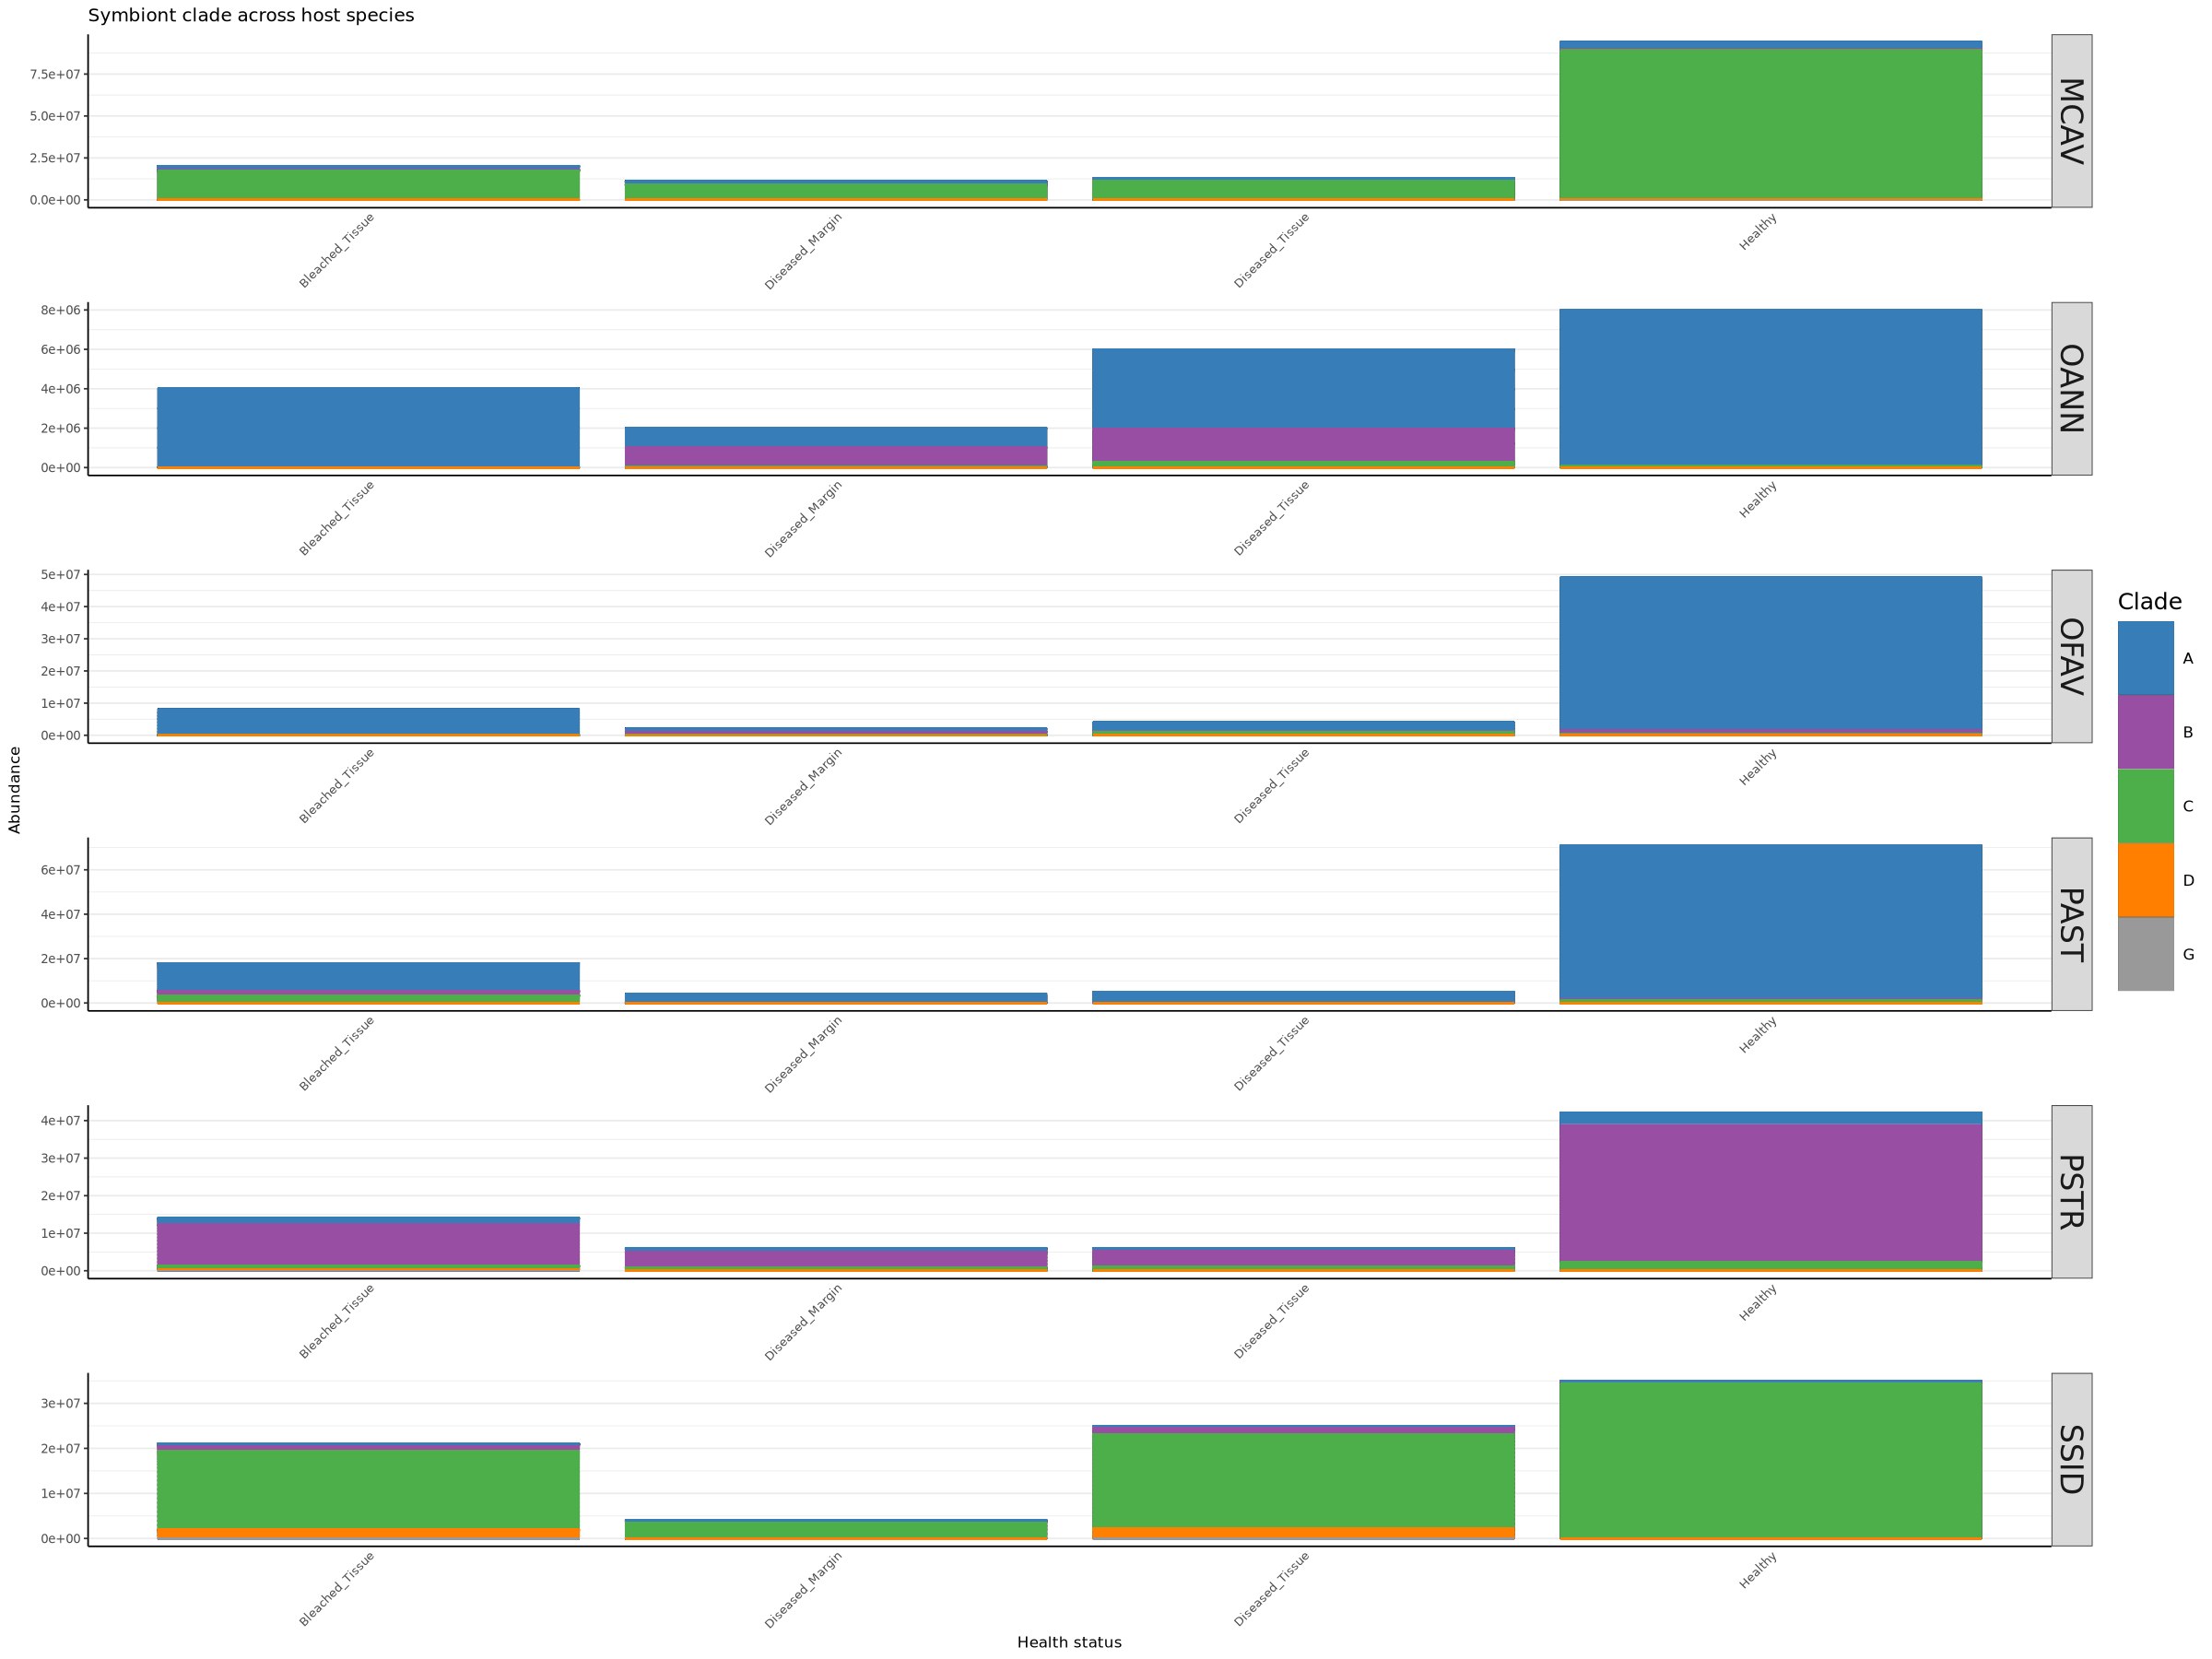

In [49]:
health_clade <- plot_bar(ps_clade, x= "Health_status", fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free") + # Set desired font size

  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Health status",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size =10)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_clade

<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


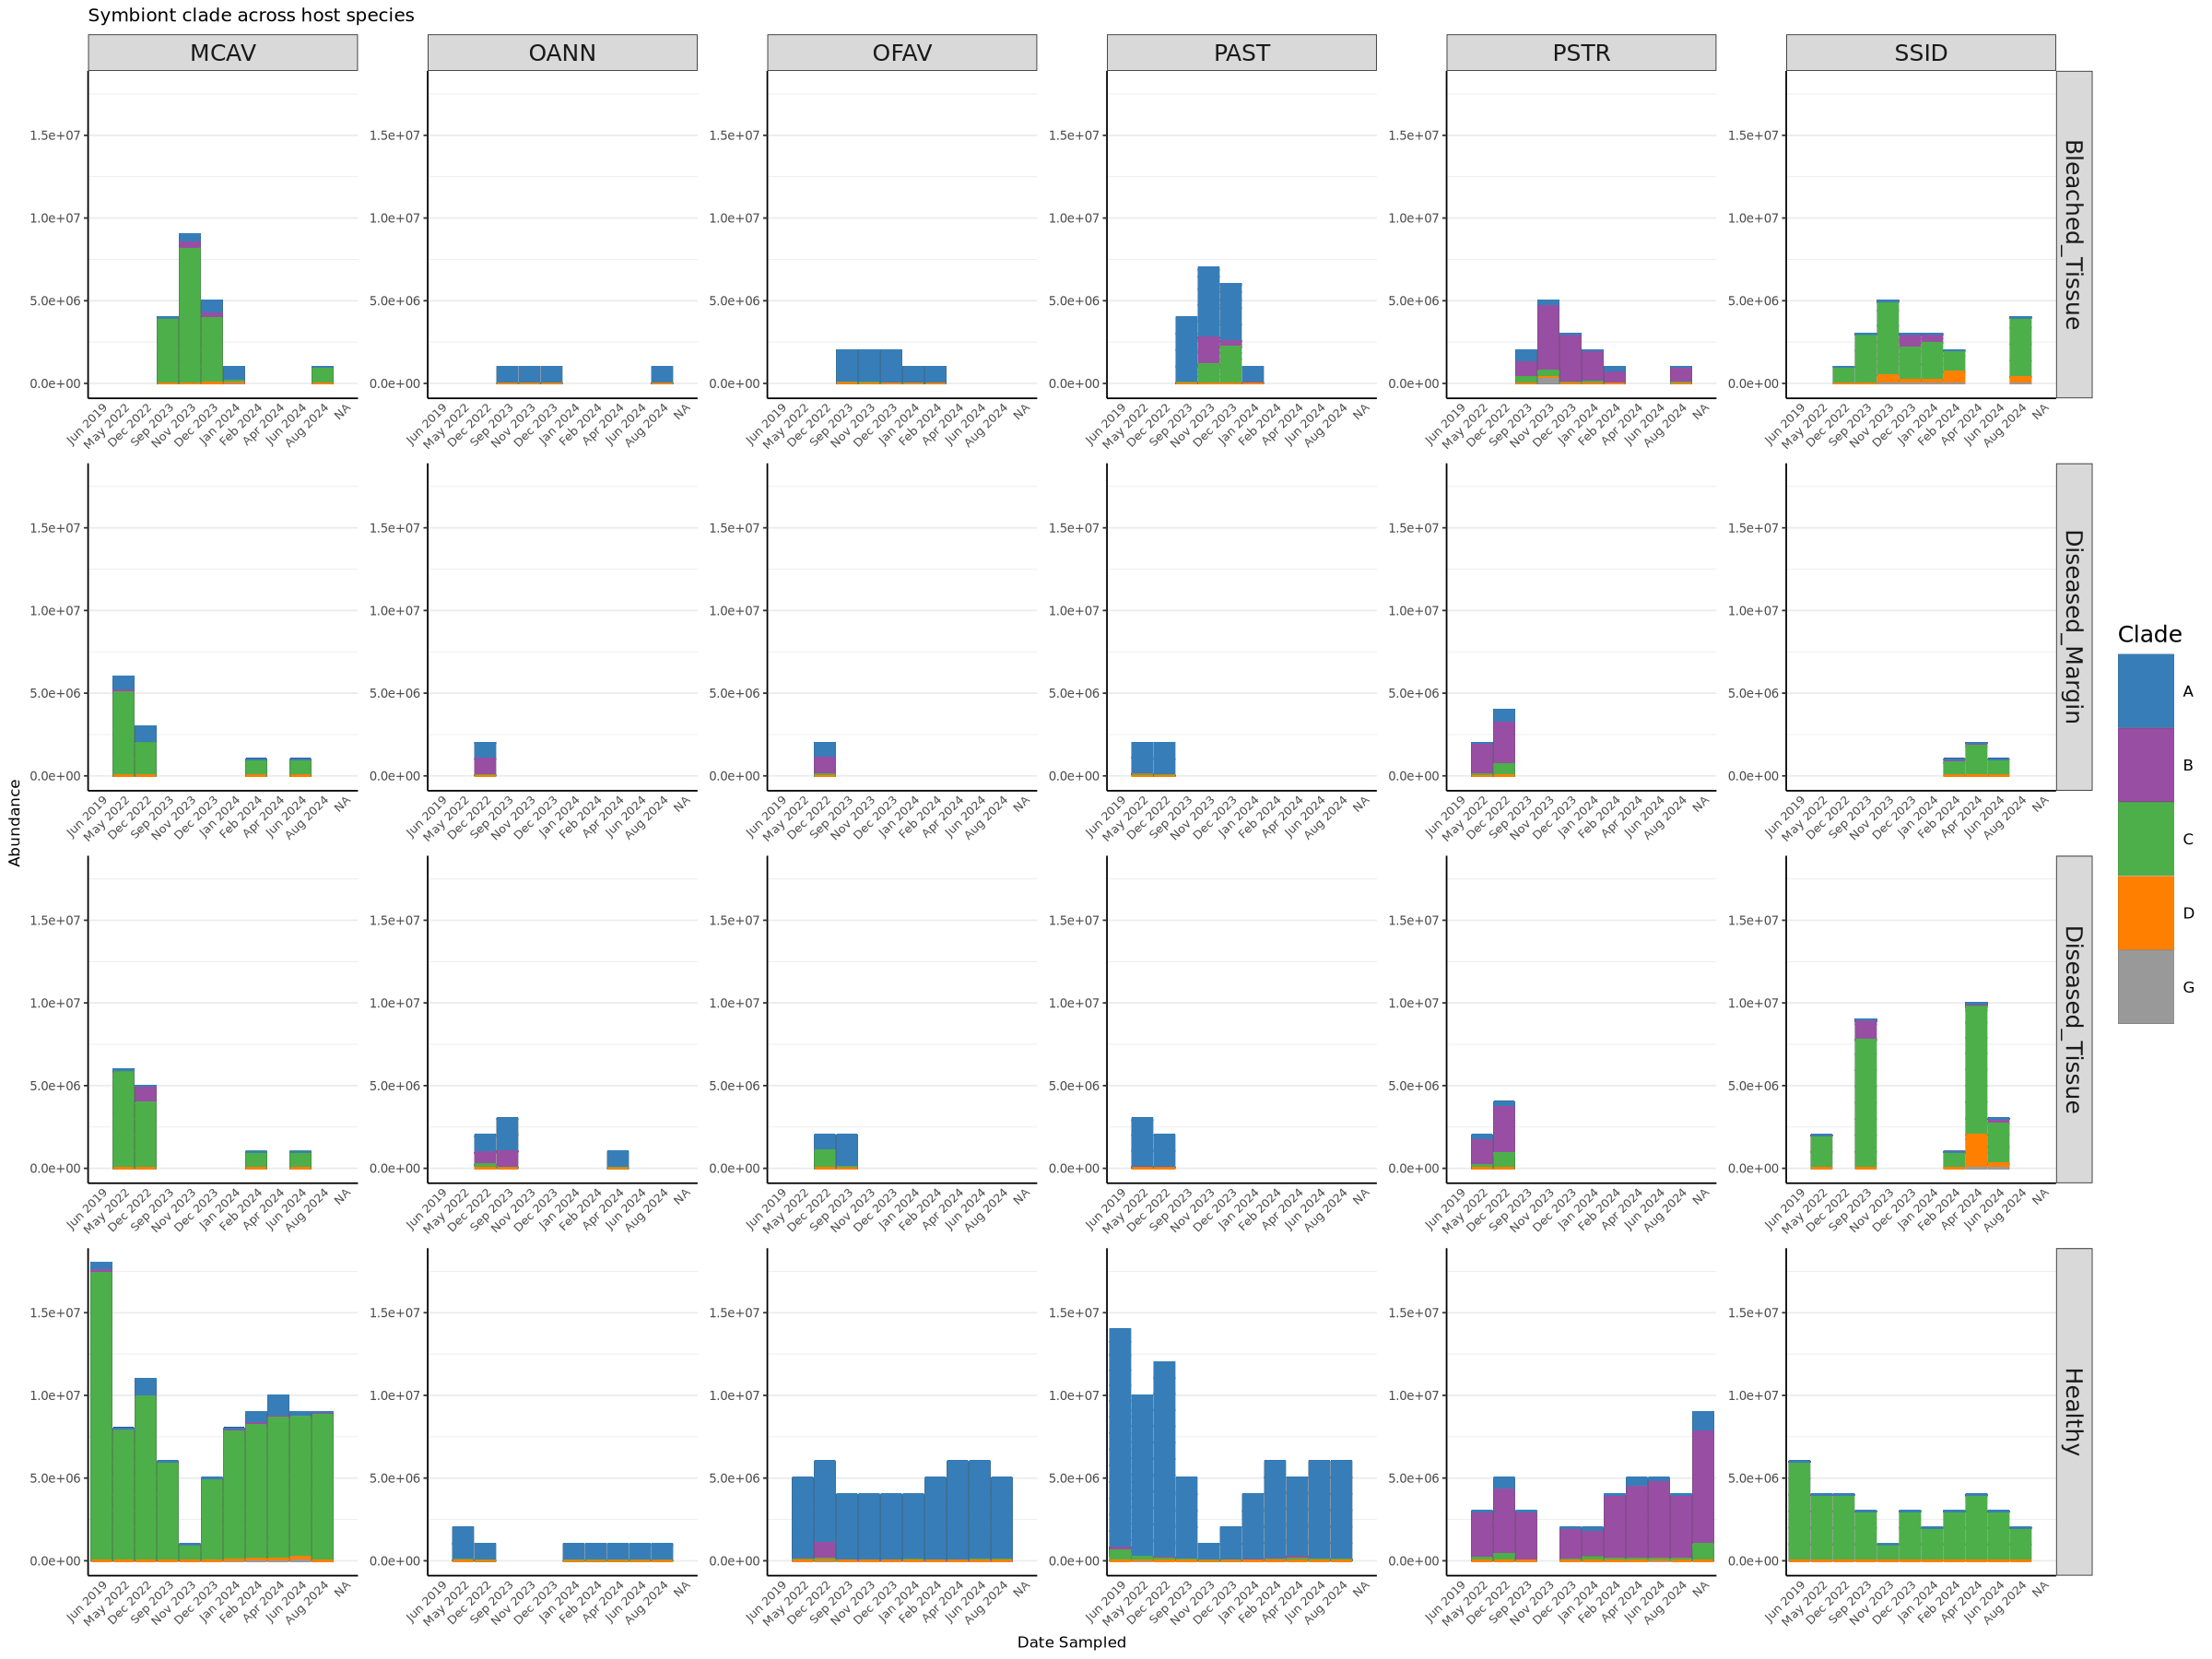

In [50]:
grid_clade <- plot_bar(ps_clade, x= "Month_year", fill = "Clade") +
facet_grid(Health_status ~ Species, axes = "all", axis.labels = "all") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Date Sampled",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 15), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size =10)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
grid_clade

### ITS2 profile by health status

In [19]:
## colors based on clade

# Extract ITS2 profiles and clades directly from phyloseq object
its2 <- psmelt(ps_norm)

profiles <- unique(as.character(its2$Majority.ITS2.sequence))
profiles <- trimws(profiles)
profiles <- profiles[!is.na(profiles)]

# Extract clade letter from each profile (e.g., "A3" -> "A")
clade <- substr(profiles, 1, 1)


In [20]:
## make a range of colors for each clade

#shift base color toward white
lighten_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  lighter <- rgb_col + (1 - rgb_col) * factor
  rgb(lighter[1], lighter[2], lighter[3])
}

#shift base color towards black
darken_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  darker <- rgb_col * (1 - factor)
  rgb(darker[1], darker[2], darker[3])
}

In [21]:
## loop for colors

profile_colors <- list()
for (cl in unique(clade)) {
  cl_profiles <- profiles[clade == cl]
  n <- length(cl_profiles)

  if (n > 0) {
    base_col <- cladecolors[[cl]]
    light_col <- lighten_color(base_col, 0.5)
    dark_col <- darken_color(base_col, 0.5) 

    ramp <- colorRampPalette(c(light_col, base_col, dark_col))(n)

    profile_colors[[cl]] <- setNames(ramp, cl_profiles)
  }
}
profile_colors <- unlist(profile_colors)

In [22]:
## removes the clade prefix from ITS2 profile name
names(profile_colors) <- sub("^[A-Z]\\.", "", names(profile_colors))

<Guides[1] ggproto object>

colour : <GuideLegend>

Ignoring unknown labels:
• colour : "Majority.ITS2.sequence"
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


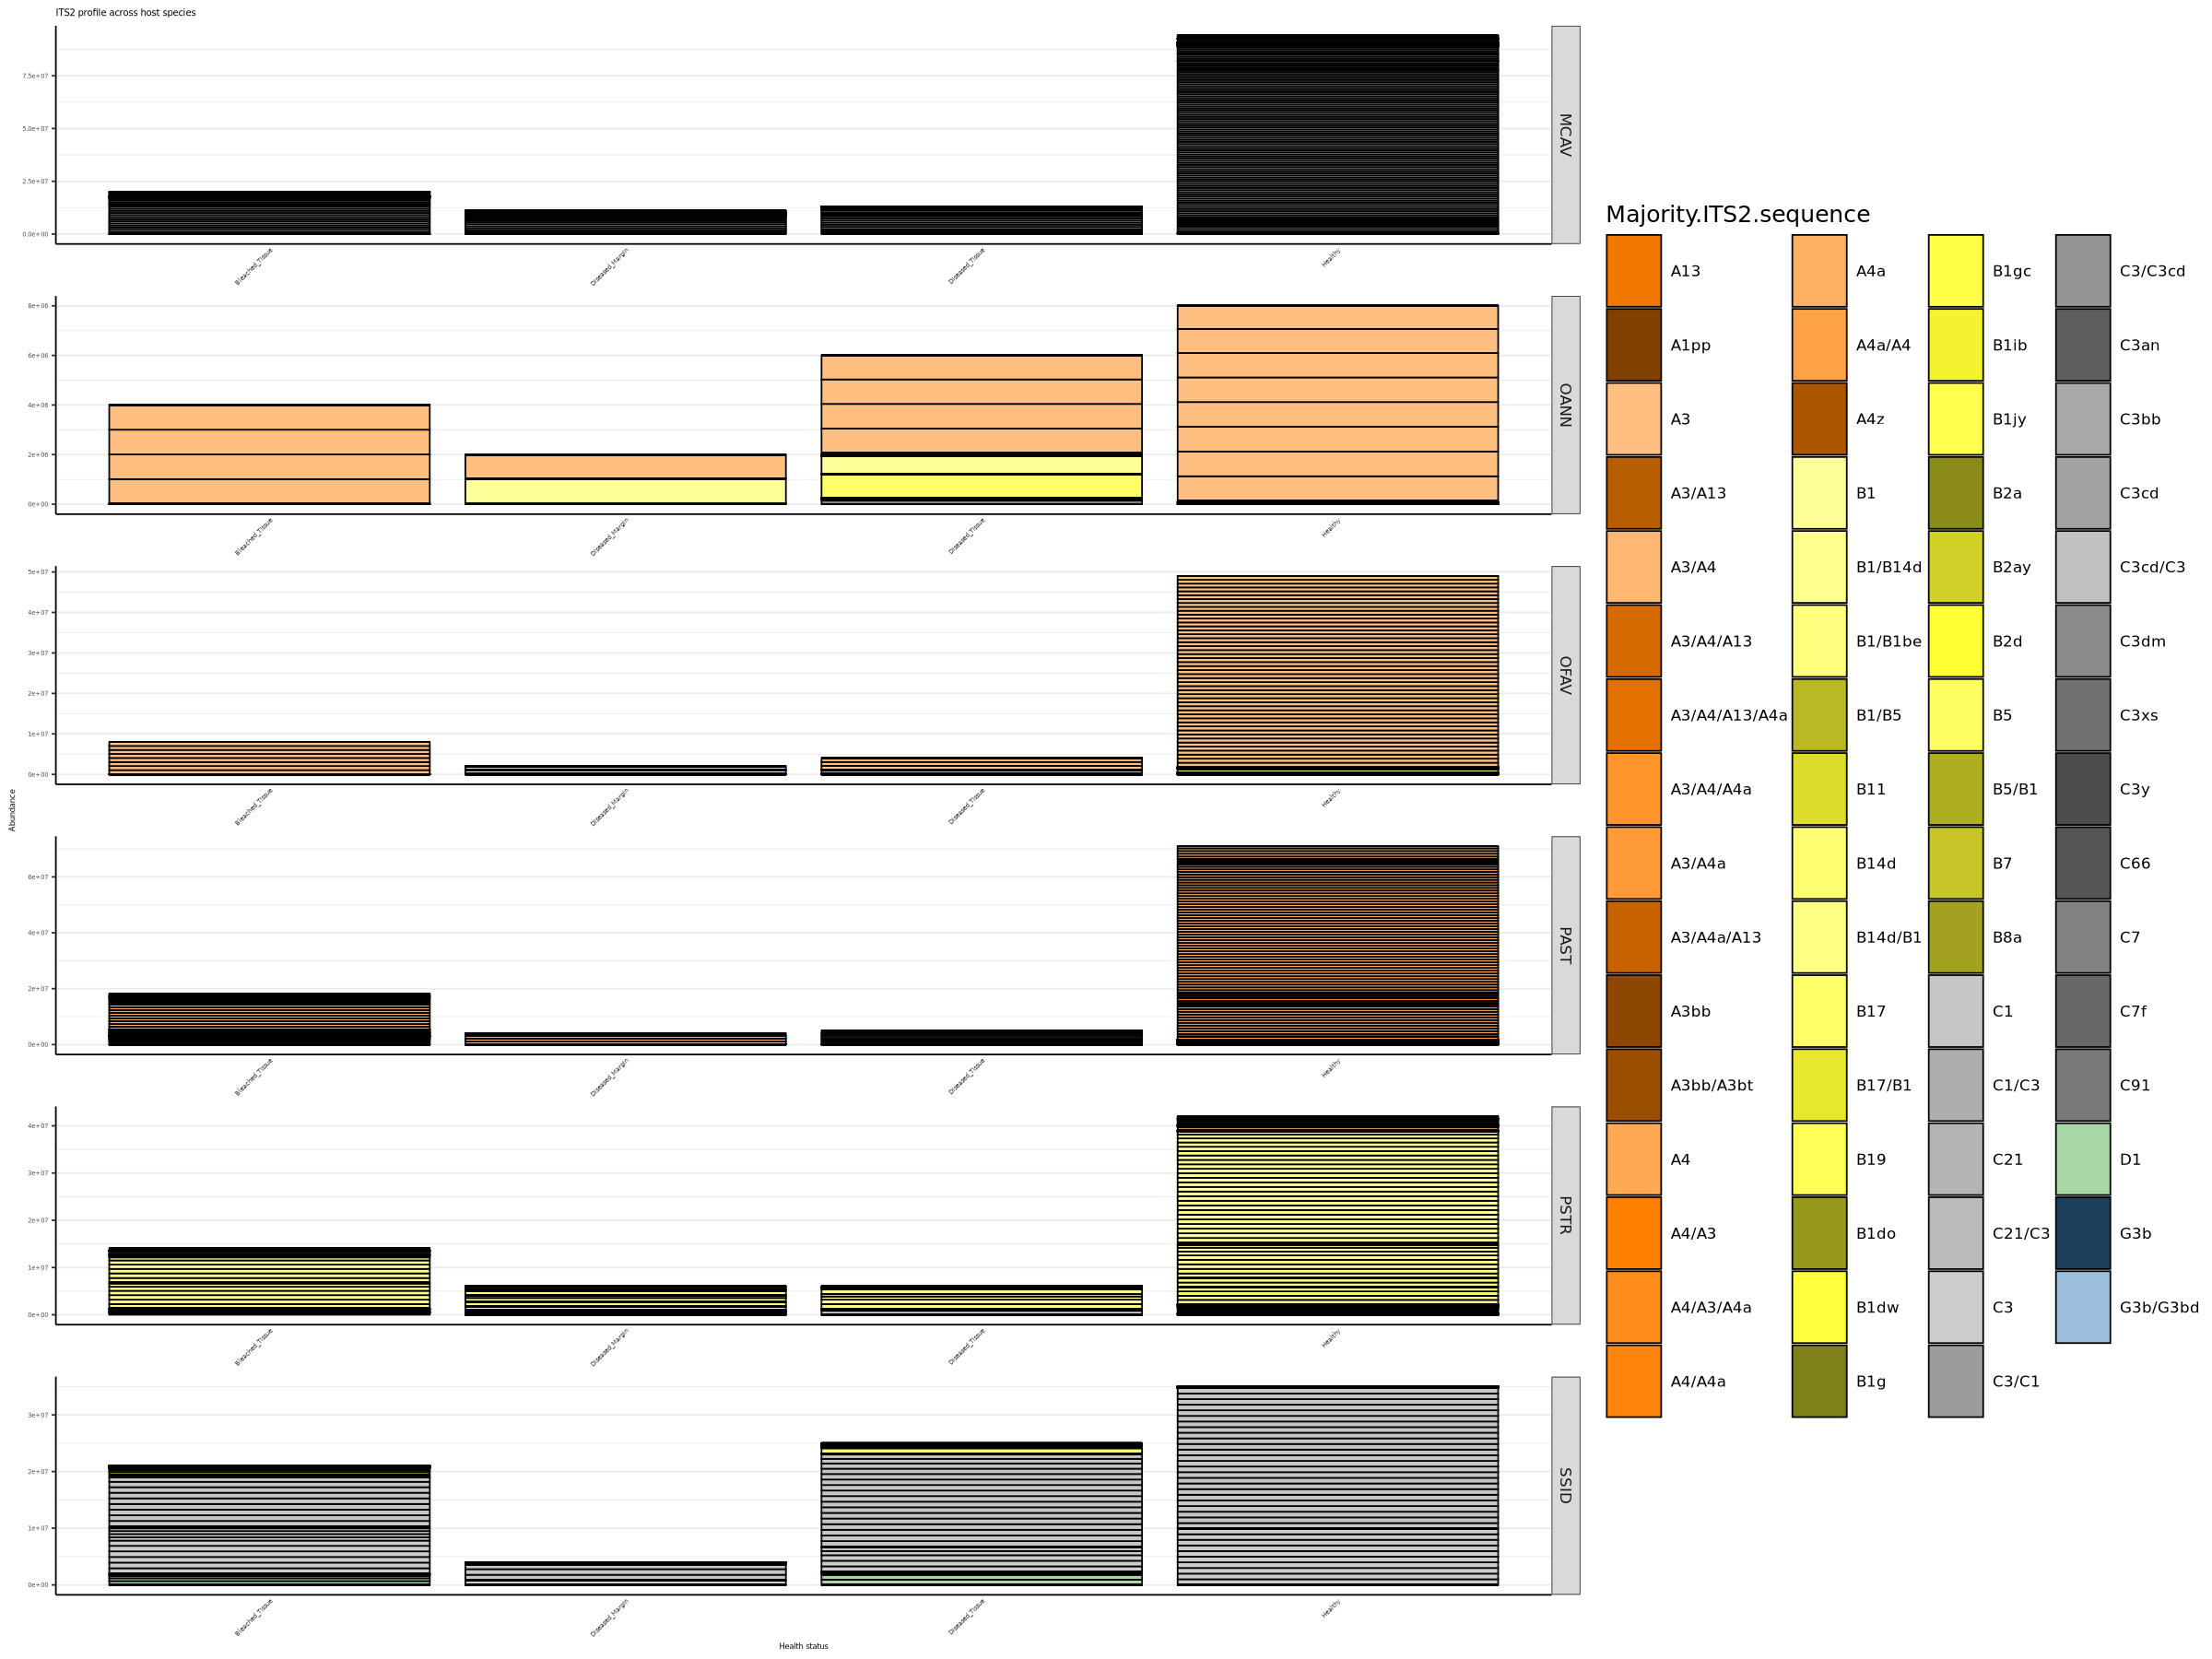

In [24]:
## plots

health_profile <- plot_bar(ps_norm, x="Health_status", fill = "Majority.ITS2.sequence") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free") + # Set desired font size
  labs(title = "ITS2 profile across host species",
       x = "Health status",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 10), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 5)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_profile